In [1]:
import numpy as np
import matplotlib.pyplot as plt

from keras.datasets.mnist import load_data
datos = load_data()

In [2]:
(X_train, y_train), (X_test, y_test) = datos

In [3]:
#Importamos el min max scaler
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()

In [4]:
#Hacemos reshape de las imagenes
X_train= X_train.reshape(-1, 28*28)
X_test = X_test.reshape(-1,28*28)
X_train.shape

(60000, 784)

In [5]:
#Categorizamos la y
from tensorflow.keras.utils import to_categorical
y_train_codificado = to_categorical(y_train)
y_test_codificado = to_categorical(y_test)

In [6]:
#Escalamos la X
X_train_escalado = scaler.fit_transform(X_train)
X_test_escalado = scaler.fit_transform(X_test)

In [7]:
X_train_escalado[2]

array([0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.     

In [8]:
X_train_escalado[2]

array([0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.     

In [9]:
from tensorflow.keras import backend as K
K.clear_session()

In [10]:
from keras.models import Sequential
from keras.layers import Dense

red = Sequential(name="miguel_ange")
red.add(Dense(1600, activation="sigmoid", input_shape=(28*28,)))
red.add(Dense(10, activation='softmax'))

c:\Users\David\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [11]:
red.summary()

Model: "miguel_ange"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 1600)           │     1,256,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │        16,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,272,010 (4.85 MB)

 Trainable params: 1,272,010 (4.85 MB)

 Non-trainable params: 0 (0.00 B)

In [12]:
red.compile(
    loss="categorical_crossentropy",
    optimizer="adam",
    metrics=["accuracy"]
)

In [13]:
#Entrenamos
h = red.fit(
    X_train_escalado, y_train_codificado,
    epochs=10,
    batch_size=16,
    validation_data=(X_test_escalado,y_test_codificado),
    verbose=False
)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


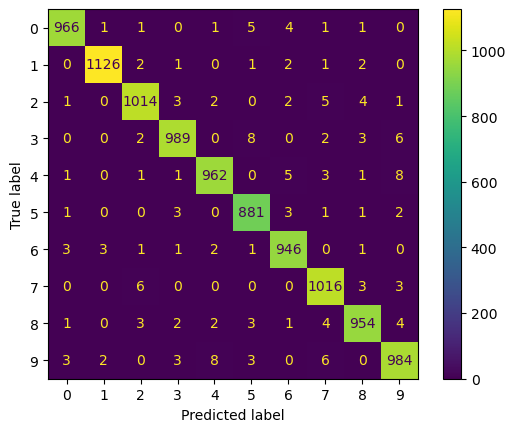

In [14]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
y_pred = red.predict(X_test_escalado)
y_pred= np.argmax(y_pred, axis=1)
cm = confusion_matrix(y_test, y_pred)
mcd = ConfusionMatrixDisplay(cm)
mcd.plot()

In [15]:
#Guardamos el modelo
from keras.models import save_model

red.save("red.h5")